**Numerical Features (10)**

1. **Administrative** - Count of administrative pages visited
2. **Administrative_Duration** - Time spent on administrative pages
3. **Informational** - Count of informational pages visited
4. **Informational_Duration** - Time spent on informational pages
5. **ProductRelated** - Count of product-related pages visited
6. **ProductRelated_Duration** - Time spent on product-related pages
7. **BounceRates** - Percentage of visitors who enter and leave without interaction
8. **ExitRates** - Percentage of pageviews that were the last in the session
9. **PageValues** - Average value for web pages before completing e-commerce transaction
10. **SpecialDay** - Closeness to special days

**Categorical Features (7)**

1. **Operating System** - Visitor's operating system
2. **Browser** - Web browser used
3. **Region** - Geographical region of visitor
4. **Traffic Type** - Traffic source type
5. **Visitor Type** - New or returning visitor
6. **Weekend** - Weekend visit indicator
7. **Month** - Month of session occurrence

**Target Variable**

* **Revenue** - Session outcome indicator
    * `True`: Session ended with shopping transaction
    * `False`: Session did not end with shopping transaction

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import os

import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")


In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
missing = df.isnull().sum()
print(missing)

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [5]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows ({duplicates/len(df)*100:.2f}% of data)")
else:
    print("No duplicate rows found!")

Found 125 duplicate rows (1.01% of data)


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

In [8]:
#Number of rows and columns within the dataset
df.shape


(12205, 18)

**Target Variable**

* **Revenue** 
    * `True`: User bought something.
    * `False`: User bought nothing.


In [9]:
target_counts = df['Revenue'].value_counts()


print("Revenue Distribution:")
print("=" * 45)
print(f"FALSE (No Purchase): {target_counts[False]:,} ({(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%)")
print(f"TRUE (Purchase):     {target_counts[True]:,} ({(target_counts[True] / (target_counts[True]+target_counts[False]))*100:.2f}%)")


Revenue Distribution:
FALSE (No Purchase): 10,297 (84.37%)
TRUE (Purchase):     1,908 (15.63%)


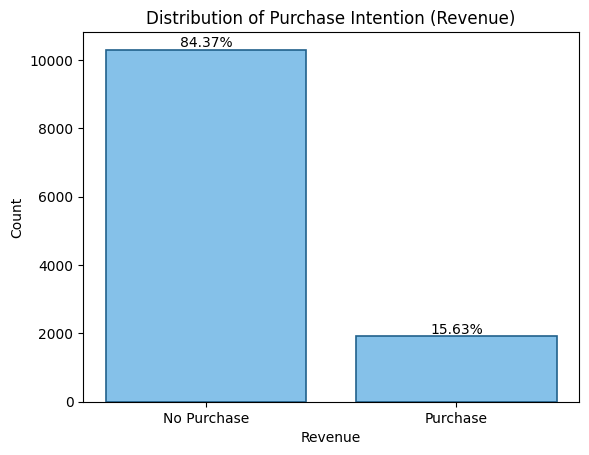

In [10]:
percentages=[f"{(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%",f"{(target_counts[True] /((target_counts[False]+target_counts[True])))*100:.2f}%"]

bars=plt.bar(["No Purchase","Purchase"],target_counts,color="#85C1E9",edgecolor="#21618C",linewidth=1.2)

plt.bar_label(bars, labels=percentages,label_type='edge')
plt.ylabel("Count")
plt.xlabel("Revenue")
plt.title("Distribution of Purchase Intention (Revenue)")
plt.grid(False)
plt.show()

**Category Data**


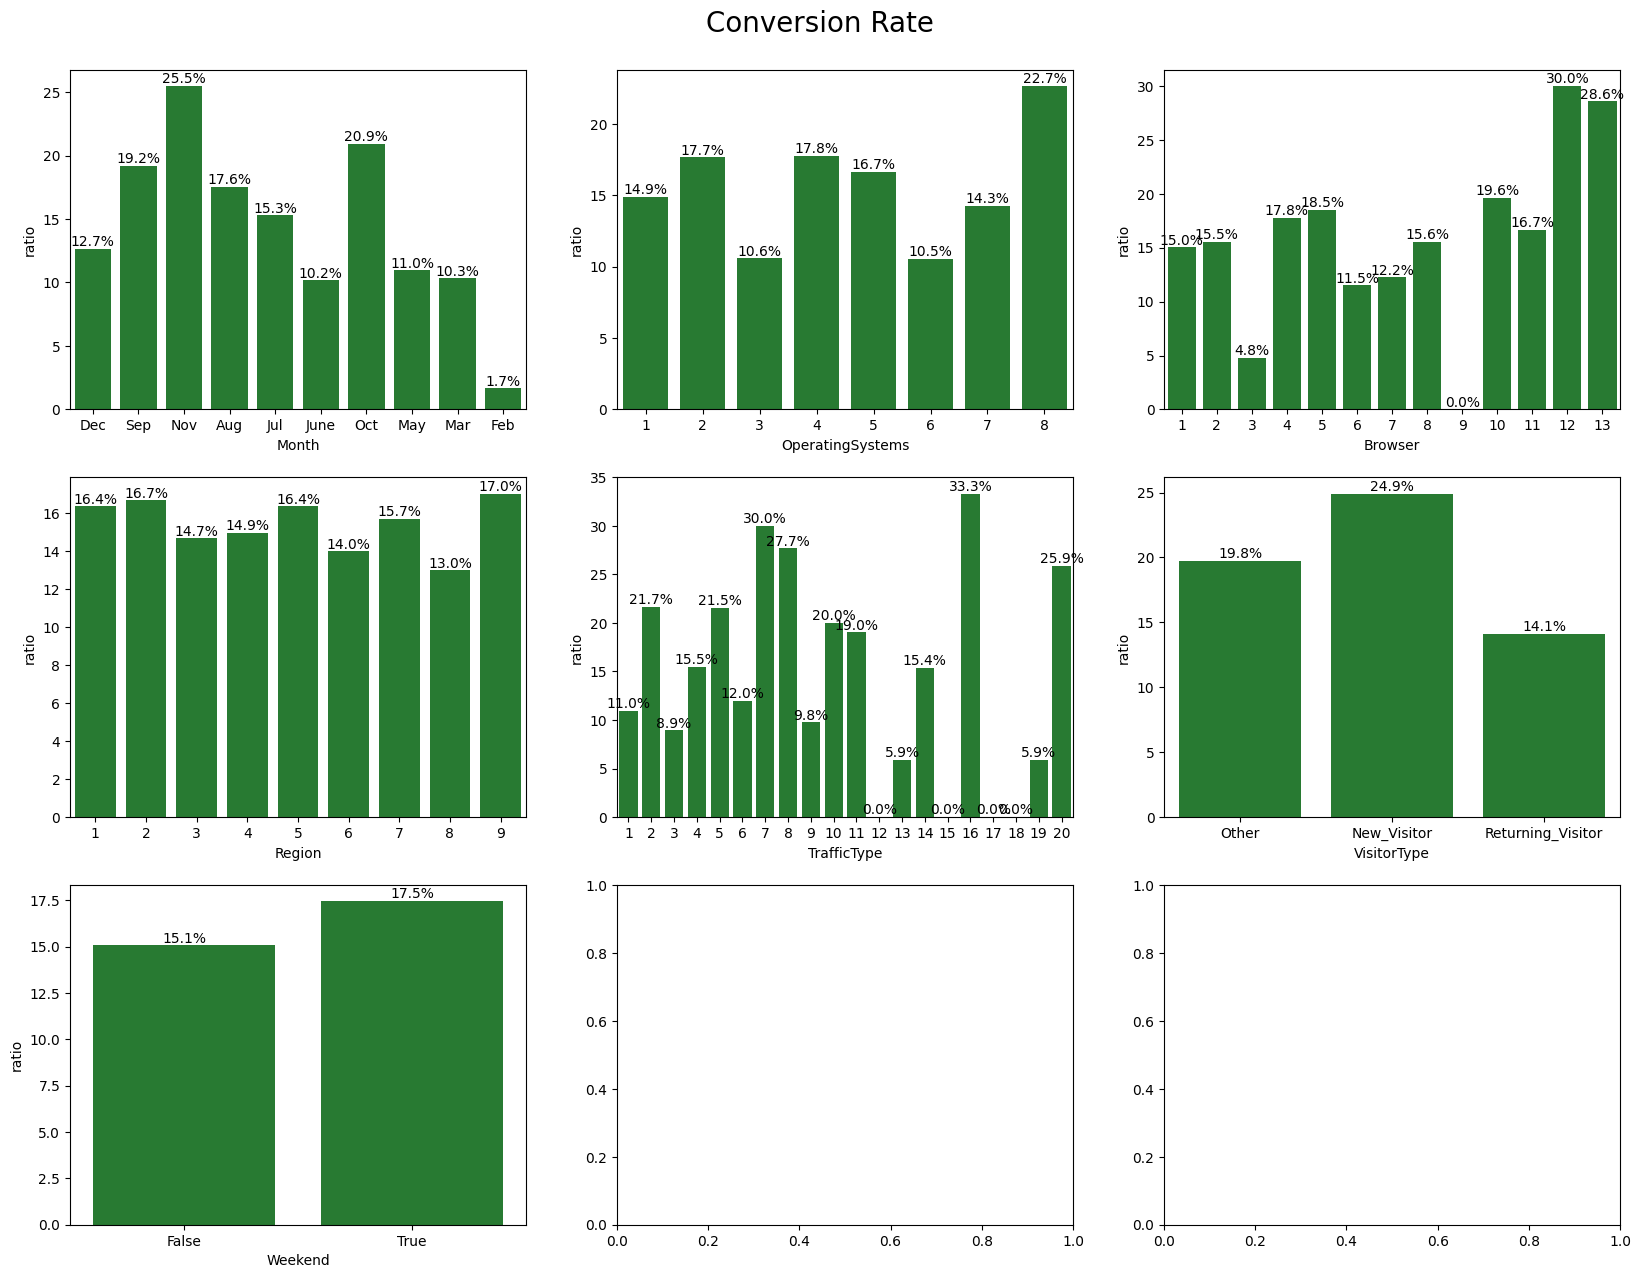

In [11]:
# sns.set(rc={"axes.facecolor":"#E7F8E6","figure.facecolor":"#E7F8E6"})
# cmap = colors.ListedColormap(["#094F29","#0A6921","#1A8828","#429B46","#64AD62","#94C58C"])

cat_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

fig, axs = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(20,15))

counter = 0

#Plotting Conversion Rate for each feature
for cat_column in cat_columns:
    df_count = pd.DataFrame(columns=[cat_column, 'ratio'])

    for t in df[cat_column].unique():
        value = df[cat_column][df[cat_column]==t][df['Revenue']==True].count()/df[cat_column][df[cat_column]==t].count()*100
        df_count = pd.concat([pd.DataFrame([[t,value]], columns=df_count.columns), df_count], ignore_index=True)
    
    fig_x = counter // 3
    fig_y = counter % 3
    sns.barplot(data=df_count, x=cat_column, y='ratio', ax=axs[fig_x, fig_y], color='#1A8828')
    axs[fig_x, fig_y].bar_label(axs[fig_x, fig_y].containers[0], fmt=lambda x: f'{x:0.1f}%', fontsize=10);

    counter += 1

fig.suptitle("Conversion Rate", fontsize=20, y=0.92)

plt.show()

In [12]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


**numerical columns**

In [13]:
print("Statistical Summary of Numerical Features:")
print("=" * 80)
numerical_features = ['Administrative', 'Administrative_Duration', 'Informational', 
                      'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                      'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
df[numerical_features].describe()

Statistical Summary of Numerical Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


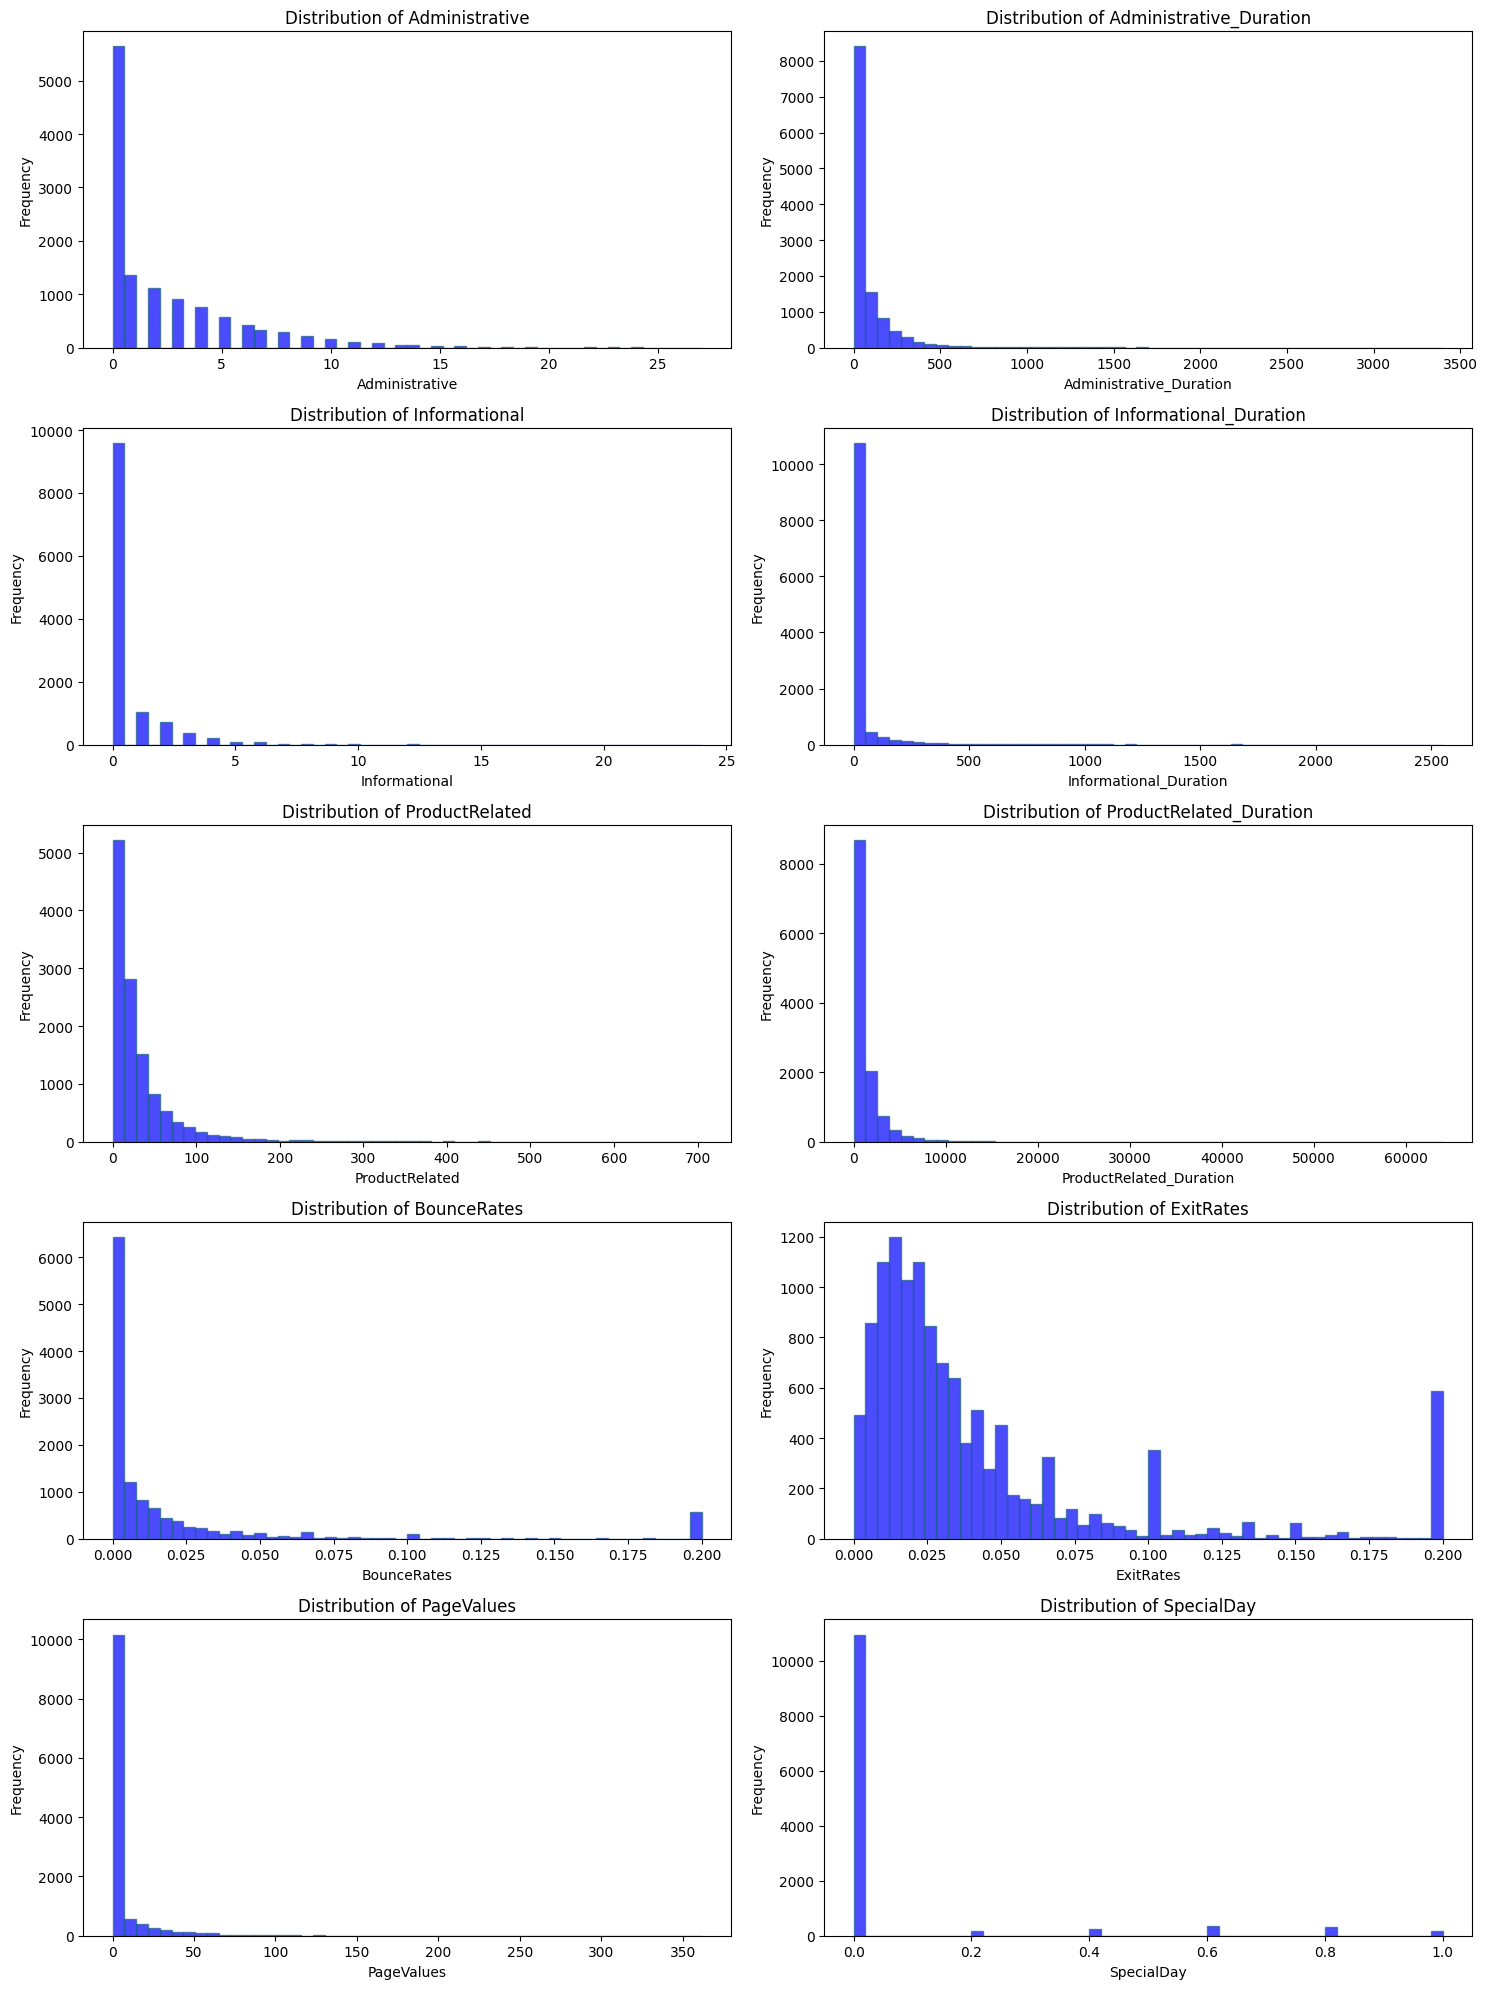

In [14]:
# Visualize Distribution of numerical features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col], bins=50, color='blue', edgecolor='#21618C', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

Most features (like ProductRelated and Administrative_Duration) are skewed to the right. This means most users browse very few pages for a short time


Correlation with Revenue:
Revenue                    1.000000
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


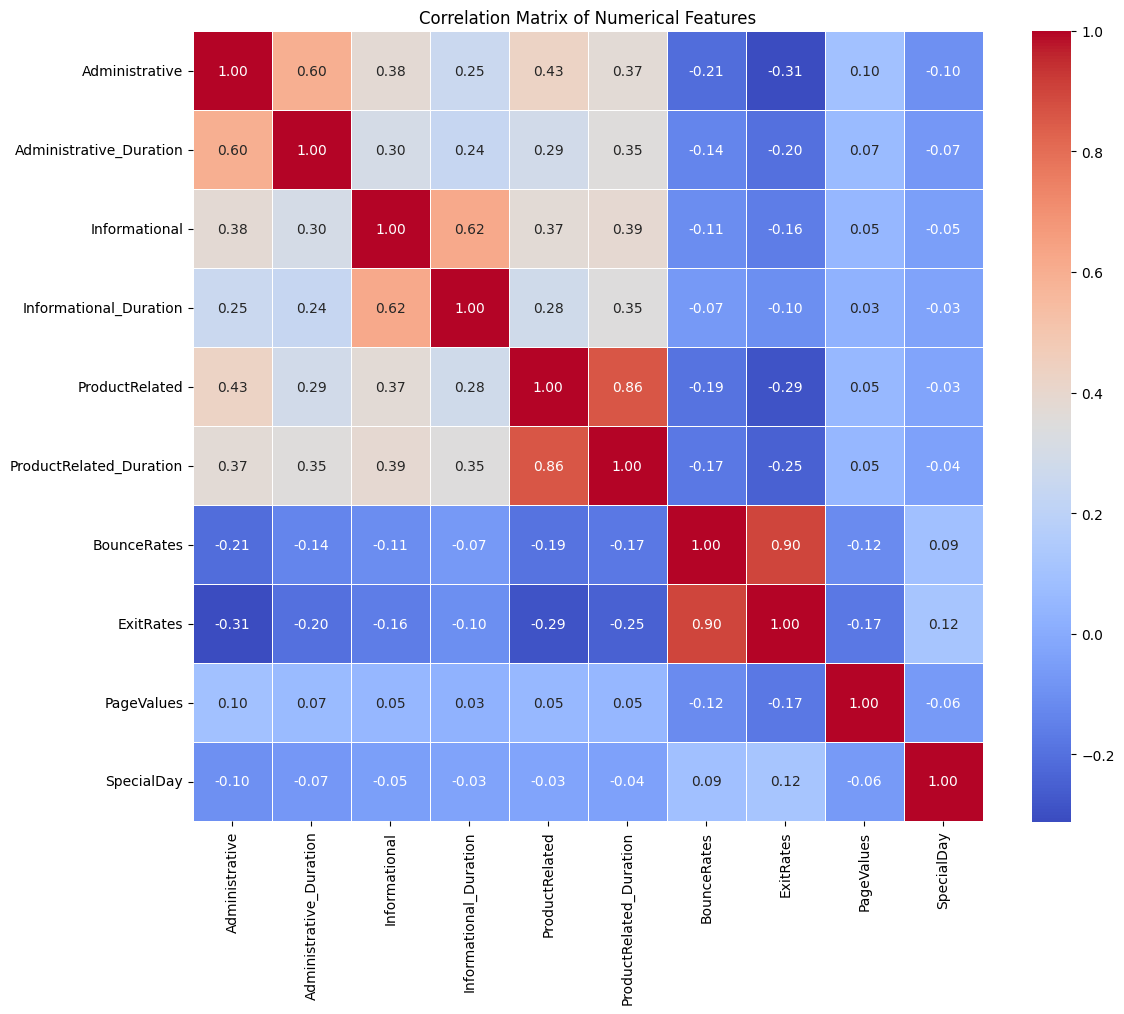

In [15]:
# Correlation Analysis

print("\nCorrelation with Revenue:")
print("=" * 50)
correlation_with_target = df[numerical_features + ['Revenue']].corr()['Revenue'].sort_values(ascending=False)
print(correlation_with_target)


plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [16]:

df_encoded = df.copy()
label_encoder = LabelEncoder()

# Encode Month 
month_order = {'Feb': 1, 'Mar': 2, 'May': 3, 'June': 4, 'Jul': 5, 
               'Aug': 6, 'Sep': 7, 'Oct': 8, 'Nov': 9, 'Dec': 10}
df_encoded['Month'] = df_encoded['Month'].map(month_order)

In [17]:
# VisitorType
df_encoded['VisitorType'] = label_encoder.fit_transform(df_encoded['VisitorType'])

In [18]:
# Weekend & Revenue
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

In [19]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 9764 (80.0%)
Test set size: 2441 (20.0%)

Training set class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test set class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

Scaled training set shape: (9764, 17)
Scaled test set shape: (2441, 17)


### Class Distribution Analysis (Training Set)

The training set exhibits a significant **class imbalance** in the target variable (`Revenue`):

* **Class 0 (False / No Purchase):** 8,238 samples (~84.4%)
* **Class 1 (True / Purchase):** 1,526 samples (~15.6%)

**The Gap:**
There is a substantial gap between the classes, with a ratio of approximately **5.4:1**. Training a model on this data directly creates a bias towards the majority class (No Purchase), causing the model to perform poorly on identifying actual buyers.

**The Solution:**
To resolve this, we will apply **SMOTE **.  create a balanced training set.

In [22]:
# Oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Oversampled training set shape: {X_train_smote.shape}")
print(f"Oversampled training set class distribution:\n{y_train_smote.value_counts()}")

Oversampled training set shape: (16476, 17)
Oversampled training set class distribution:
Revenue
1    8238
0    8238
Name: count, dtype: int64


**Classification**

In [23]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
import time

# Define models with their parameter grids for GridSearchCV
models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    }
}

In [24]:
# Perform GridSearchCV for each model
results = {}
best_models = {}

print("=" * 70)
print("HYPERPARAMETER TUNING WITH GRID SEARCH CV (Using SMOTE Data)")
print("=" * 70)

for name, mp in models_params.items():
    print(f"\n{'='*50}")
    print(f"Training {name} with GridSearchCV...")
    print(f"{'='*50}")
    
    start_time = time.time()
    
    # GridSearchCV with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit on SMOTE-resampled training data for better handling of class imbalance
    grid_search.fit(X_train_smote, y_train_smote)
    
    training_time = time.time() - start_time
    
    # Get best model
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Make predictions on original (non-SMOTE) test data
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Best_Params': grid_search.best_params_,
        'Best_CV_Score': grid_search.best_score_,
        'Training_Time': training_time,
        'Model': best_model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1-Score: {f1:.4f}")
    print(f"Test ROC-AUC: {roc_auc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

HYPERPARAMETER TUNING WITH GRID SEARCH CV (Using SMOTE Data)

Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.8201
Test Accuracy: 0.8816
Test F1-Score: 0.6734
Test ROC-AUC: 0.9083
Training Time: 27.61 seconds

Training Decision Tree with GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-Score: 0.8936
Test Accuracy: 0.8624
Test F1-Score: 0.6066
Test ROC-AUC: 0.8035
Training Time: 23.88 seconds

Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.9341
Test Accuracy: 0.8906
Test F1-Score: 0.6771
Test ROC-AUC: 0.9259
Tra

In [25]:
# Create results summary DataFrame
results_df = pd.DataFrame({
    name: {
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score'],
        'ROC-AUC': res['ROC-AUC'],
        'CV F1-Score': res['Best_CV_Score'],
        'Training Time (s)': res['Training_Time']
    } for name, res in results.items()
}).T

results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY (After GridSearchCV)")
print("=" * 70)
print(results_df.to_string())

# Identify best model
best_model_name = results_df['F1-Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   Precision: {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")


MODEL PERFORMANCE SUMMARY (After GridSearchCV)
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC  CV F1-Score  Training Time (s)
XGBoost              0.895944   0.648148  0.732984  0.687961  0.935072     0.916402          35.298919
Random Forest        0.890619   0.629213  0.732984  0.677146  0.925901     0.934082         235.539814
Logistic Regression  0.881606   0.592445  0.780105  0.673446  0.908349     0.820064          27.609465
Decision Tree        0.862351   0.548729  0.678010  0.606557  0.803453     0.893562          23.881668

🏆 BEST MODEL: XGBoost
   Accuracy: 0.8959
   Precision: 0.6481
   F1-Score: 0.6880
   ROC-AUC: 0.9351


## Model Comparison Visualizations
Comparing all models across different performance metrics after GridSearchCV hyperparameter tuning.

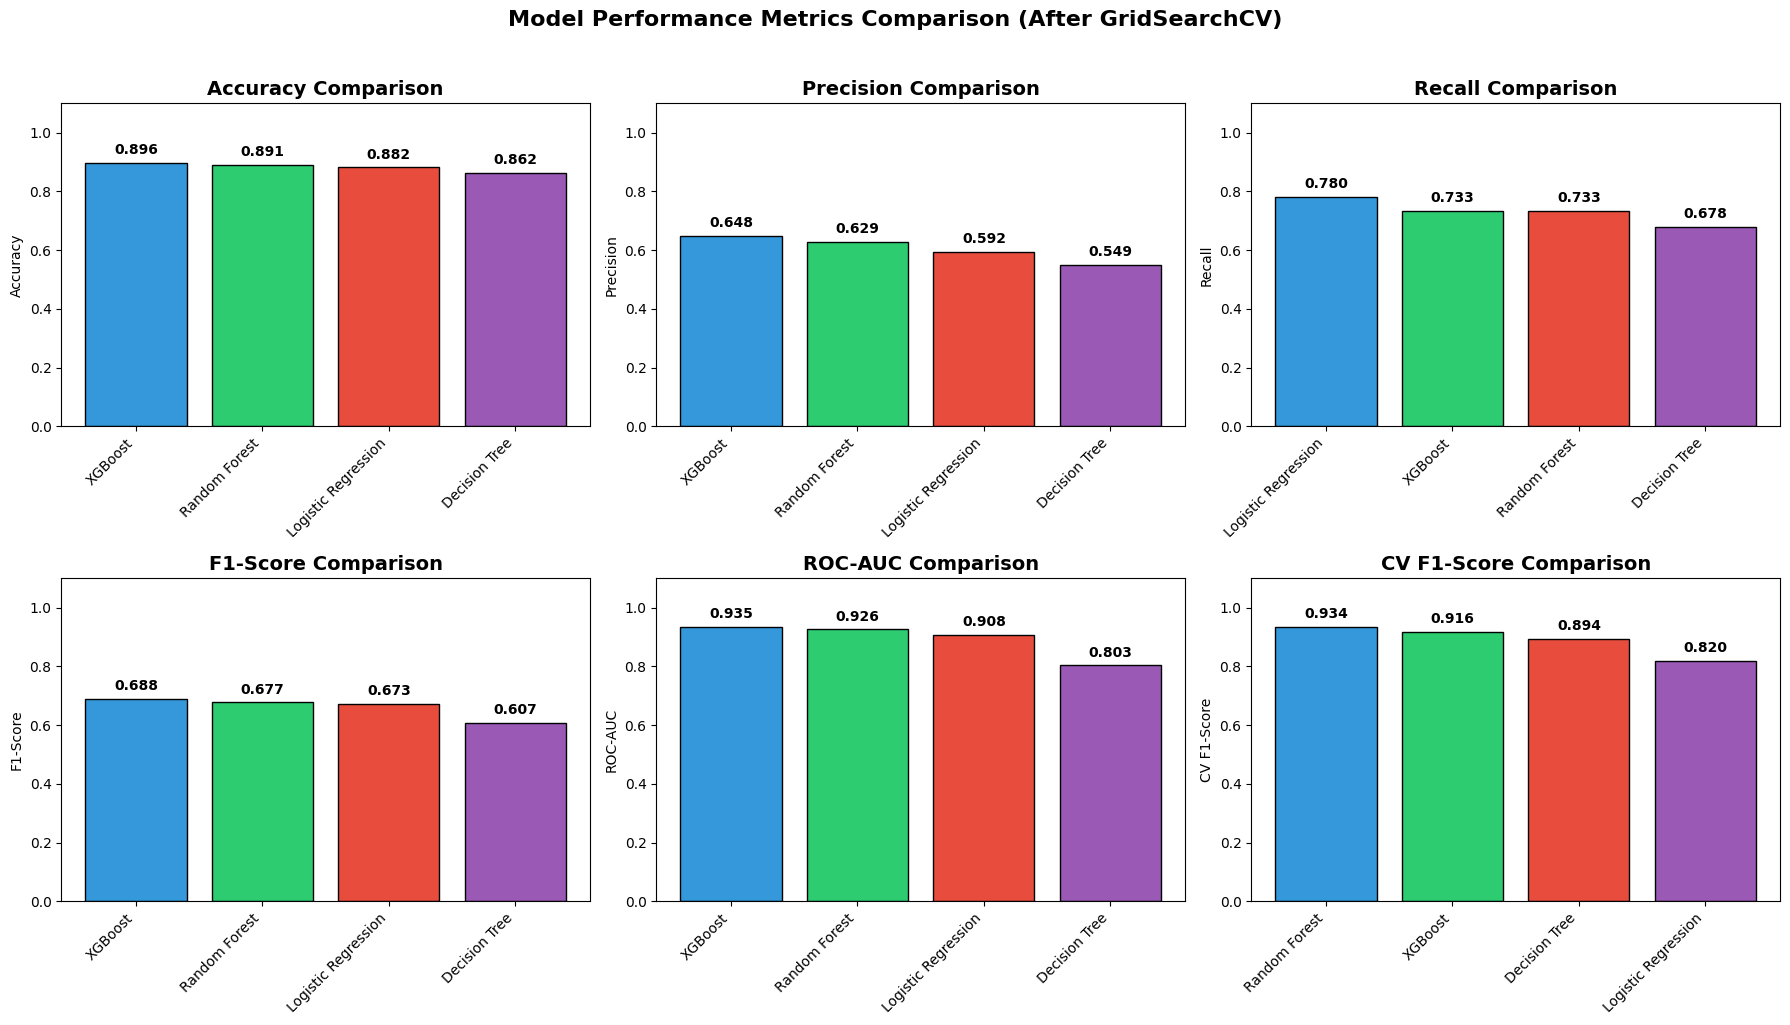

In [26]:
# 1. Performance Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1-Score']
colors_palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    sorted_df = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(range(len(sorted_df)), sorted_df[metric], color=colors_palette, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df.index, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Metrics Comparison (After GridSearchCV)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

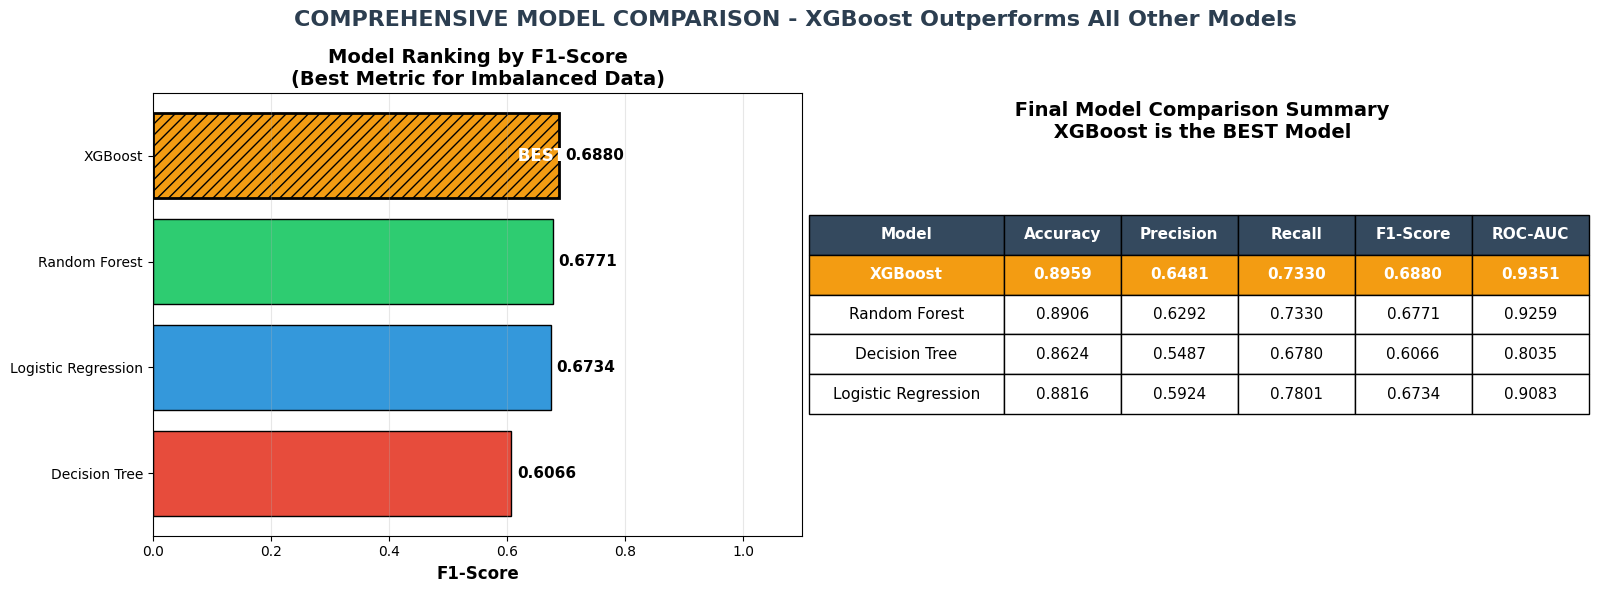


 CONCLUSION: XGBoost is the BEST MODEL for this dataset!

XGBoost achieves the highest scores across all key metrics:
   ✅ Accuracy:    0.8959
   ✅ Precision:   0.6481
   ✅ Recall:      0.7330
   ✅ F1-Score:    0.6880
   ✅ ROC-AUC:     0.9351



In [27]:
# XGBoost Model Comparison - Horizontal Bar & Summary Table
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define color dictionary
colors_dict = {'Logistic Regression': '#3498db', 'Decision Tree': '#e74c3c', 
               'Random Forest': '#2ecc71', 'XGBoost': '#f39c12'}

# 1. Horizontal Bar - Ranking by F1-Score (Best Metric for Imbalanced Data)
ax1 = axes[0]
sorted_models = results_df.sort_values('F1-Score', ascending=True)
colors_bars = [colors_dict[name] for name in sorted_models.index]
bars = ax1.barh(sorted_models.index, sorted_models['F1-Score'], color=colors_bars, edgecolor='black')
bars[-1].set_hatch('///')  # XGBoost at top
bars[-1].set_linewidth(2)

for i, (bar, score) in enumerate(zip(bars, sorted_models['F1-Score'])):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
    if sorted_models.index[i] == 'XGBoost':
        ax1.text(bar.get_width() - 0.08, bar.get_y() + bar.get_height()/2,
                 ' BEST', va='center', fontsize=12, fontweight='bold', color='white')

ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Ranking by F1-Score\n(Best Metric for Imbalanced Data)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.1)
ax1.grid(axis='x', alpha=0.3)

# 2. Summary Table with Winner Highlight
ax2 = axes[1]
ax2.axis('off')

# Create summary table
summary_data = []
for name in ['XGBoost', 'Random Forest', 'Decision Tree', 'Logistic Regression']:
    res = results[name]
    summary_data.append([
        name,
        f"{res['Accuracy']:.4f}",
        f"{res['Precision']:.4f}",
        f"{res['Recall']:.4f}",
        f"{res['F1-Score']:.4f}",
        f"{res['ROC-AUC']:.4f}"
    ])

table = ax2.table(cellText=summary_data,
                  colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                  loc='center',
                  cellLoc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# Highlight XGBoost row (first data row)
for j in range(6):
    table[(1, j)].set_facecolor('#f39c12')
    table[(1, j)].set_text_props(fontweight='bold', color='white')
    table[(0, j)].set_facecolor('#34495e')
    table[(0, j)].set_text_props(fontweight='bold', color='white')

ax2.set_title(' Final Model Comparison Summary\n XGBoost is the BEST Model', 
              fontsize=14, fontweight='bold', y=0.88)

plt.suptitle('COMPREHENSIVE MODEL COMPARISON - XGBoost Outperforms All Other Models', 
             fontsize=16, fontweight='bold', y=0.98, color='#2c3e50')
plt.tight_layout()
plt.show()

# Print final verdict
print("\n" + "="*70)
print(" CONCLUSION: XGBoost is the BEST MODEL for this dataset!")
print("="*70)
print(f"\nXGBoost achieves the highest scores across all key metrics:")
xgb_res = results['XGBoost']
print(f"   ✅ Accuracy:    {xgb_res['Accuracy']:.4f}")
print(f"   ✅ Precision:   {xgb_res['Precision']:.4f}")
print(f"   ✅ Recall:      {xgb_res['Recall']:.4f}")
print(f"   ✅ F1-Score:    {xgb_res['F1-Score']:.4f}")
print(f"   ✅ ROC-AUC:     {xgb_res['ROC-AUC']:.4f}")
print("\n" + "="*70)

## XGBoost Feature Importance Analysis
Analyzing which features contribute most to predicting purchase intention using XGBoost's built-in feature importance.

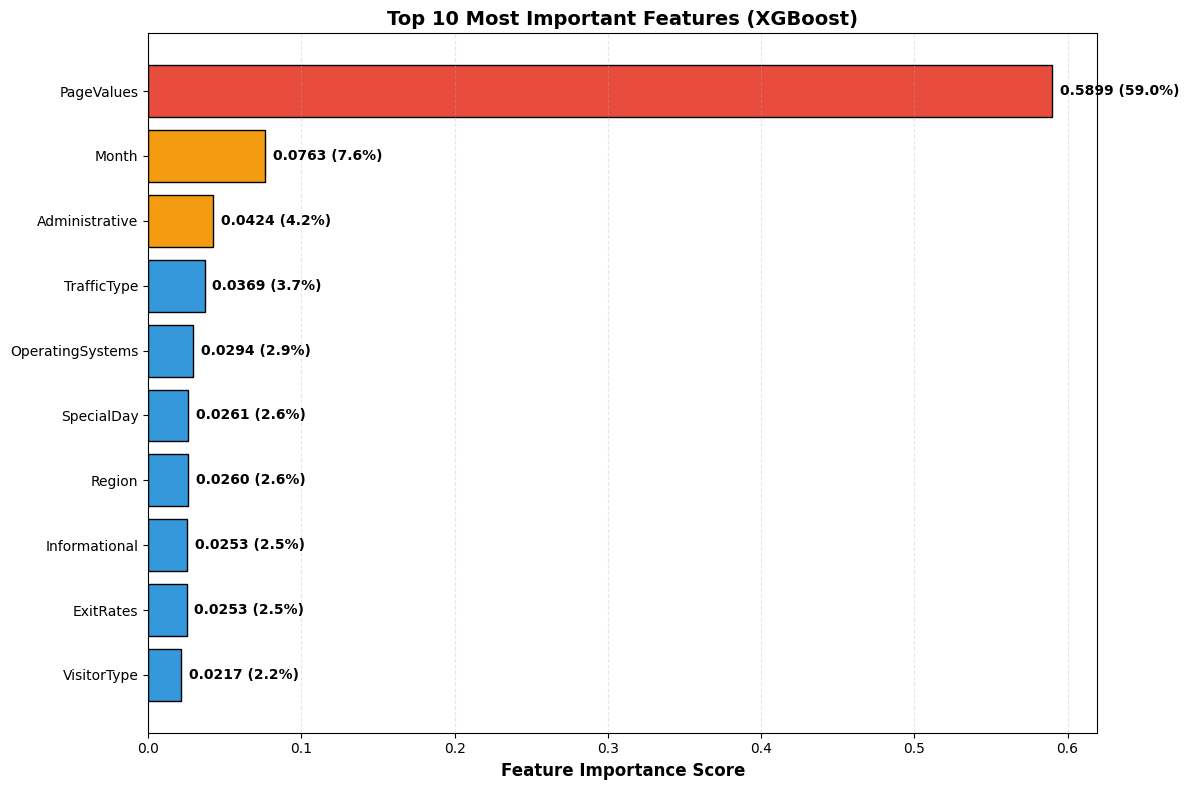


TOP 10 MOST IMPORTANT FEATURES

Rank  Feature                       Importance     Percentage
-----------------------------------------------------------------
1     PageValues                    0.5899         58.99%
2     Month                         0.0763         7.63%
3     Administrative                0.0424         4.24%
4     TrafficType                   0.0369         3.69%
5     OperatingSystems              0.0294         2.94%
6     SpecialDay                    0.0261         2.61%
7     Region                        0.0260         2.60%
8     Informational                 0.0253         2.53%
9     ExitRates                     0.0253         2.53%
10    VisitorType                   0.0217         2.17%


In [28]:
# Extract XGBoost model and feature importance
xgb_model = best_models['XGBoost']
feature_names = X.columns.tolist()

# Get feature importance (using 'weight' - number of times feature is used to split)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Create figure for Top 10 features
fig, ax = plt.subplots(figsize=(12, 8))

top_10 = importance_df.head(10)
colors_top10 = ['#e74c3c' if i == 0 else '#f39c12' if i < 3 else '#3498db' 
                for i in range(len(top_10))]
bars = ax.barh(top_10['Feature'], top_10['Importance'], color=colors_top10, edgecolor='black')
ax.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add percentage labels
total_importance = importance_df['Importance'].sum()
for bar, (_, row) in zip(bars, top_10.iterrows()):
    width = bar.get_width()
    pct = (row['Importance'] / total_importance) * 100
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.4f} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 70)
print(f"\n{'Rank':<6}{'Feature':<30}{'Importance':<15}{'Percentage':<10}")
print("-" * 65)
for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    pct = (row['Importance'] / total_importance) * 100
    print(f"{i:<6}{row['Feature']:<30}{row['Importance']:<15.4f}{pct:.2f}%")



In [29]:
# 7. Best Hyperparameters Summary
print("=" * 70)
print("BEST HYPERPARAMETERS FOR EACH MODEL")
print("=" * 70)

for name, res in results.items():
    print(f"\n{name}:")
    print("-" * 40)
    for param, value in res['Best_Params'].items():
        print(f"  {param}: {value}")

BEST HYPERPARAMETERS FOR EACH MODEL

Logistic Regression:
----------------------------------------
  C: 0.001
  penalty: l1
  solver: liblinear

Decision Tree:
----------------------------------------
  criterion: gini
  max_depth: 15
  min_samples_leaf: 1
  min_samples_split: 2

Random Forest:
----------------------------------------
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

XGBoost:
----------------------------------------
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 50
  subsample: 0.8


In [30]:
# 9. Final Model Recommendation
print("\n" + "=" * 70)
print("🏆 FINAL MODEL RECOMMENDATION")
print("=" * 70)

best_name = results_df['F1-Score'].idxmax()
best_res = results[best_name]

print(f"\nBased on GridSearchCV hyperparameter tuning, the BEST model is:")
print(f"\n   📌 {best_name}")
print(f"\n   Performance Metrics:")
print(f"   ├── Accuracy:    {best_res['Accuracy']:.4f}")
print(f"   ├── Precision:   {best_res['Precision']:.4f}")
print(f"   ├── Recall:      {best_res['Recall']:.4f}")
print(f"   ├── F1-Score:    {best_res['F1-Score']:.4f}")
print(f"   └── ROC-AUC:     {best_res['ROC-AUC']:.4f}")
print(f"\n   Best Hyperparameters:")
for param, value in best_res['Best_Params'].items():
    print(f"   ├── {param}: {value}")
print(f"\n   Cross-Validation F1-Score: {best_res['Best_CV_Score']:.4f}")
print(f"   Training Time: {best_res['Training_Time']:.2f} seconds")
print("\n" + "=" * 70)


🏆 FINAL MODEL RECOMMENDATION

Based on GridSearchCV hyperparameter tuning, the BEST model is:

   📌 XGBoost

   Performance Metrics:
   ├── Accuracy:    0.8959
   ├── Precision:   0.6481
   ├── Recall:      0.7330
   ├── F1-Score:    0.6880
   └── ROC-AUC:     0.9351

   Best Hyperparameters:
   ├── colsample_bytree: 0.8
   ├── learning_rate: 0.1
   ├── max_depth: 7
   ├── n_estimators: 50
   ├── subsample: 0.8

   Cross-Validation F1-Score: 0.9164
   Training Time: 35.30 seconds



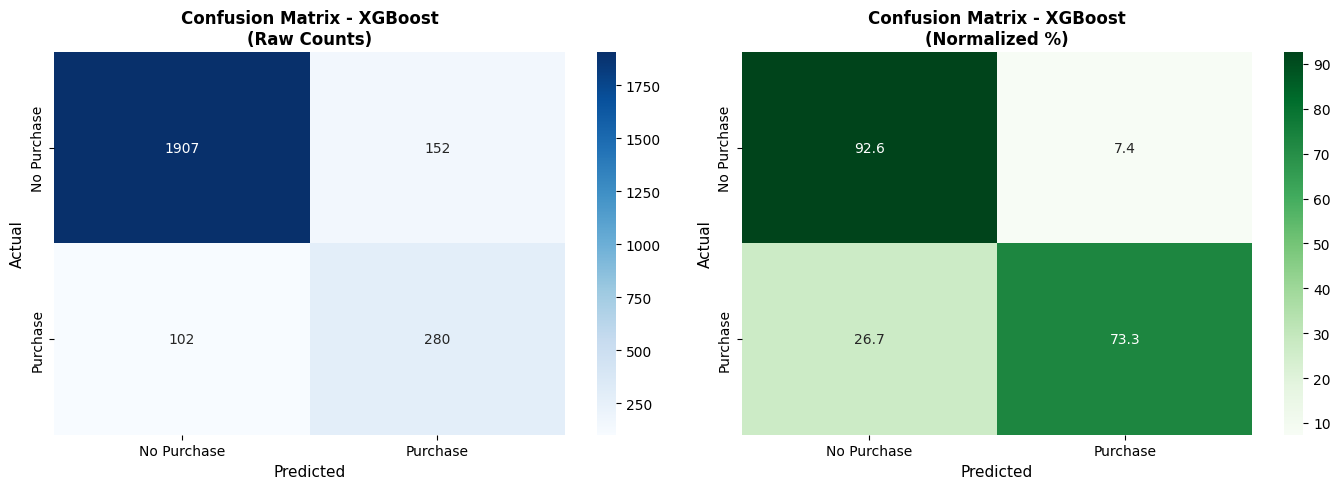


📊 CONFUSION MATRIX INTERPRETATION

✅ True Negatives (TN):  1,907 - Correctly predicted NO purchase
❌ False Positives (FP): 152 - Incorrectly predicted purchase
❌ False Negatives (FN): 102 - Missed actual purchases
✅ True Positives (TP):  280 - Correctly predicted purchase

📈 Model correctly identifies 73.3% of actual buyers (Recall)
📈 Model correctly identifies 92.6% of non-buyers (Specificity)


In [31]:
# Confusion Matrix Visualization for Best Model (XGBoost)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the best model
y_pred = best_models[best_name].predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
axes[0].set_title(f'Confusion Matrix - {best_name}\n(Raw Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

# Plot 2: Normalized (Percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
axes[1].set_title(f'Confusion Matrix - {best_name}\n(Normalized %)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('exports/charts/confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Print interpretation
print("\n" + "=" * 60)
print("📊 CONFUSION MATRIX INTERPRETATION")
print("=" * 60)
print(f"\n✅ True Negatives (TN):  {cm[0,0]:,} - Correctly predicted NO purchase")
print(f"❌ False Positives (FP): {cm[0,1]:,} - Incorrectly predicted purchase")
print(f"❌ False Negatives (FN): {cm[1,0]:,} - Missed actual purchases")
print(f"✅ True Positives (TP):  {cm[1,1]:,} - Correctly predicted purchase")
print(f"\n📈 Model correctly identifies {cm_normalized[1,1]:.1f}% of actual buyers (Recall)")
print(f"📈 Model correctly identifies {cm_normalized[0,0]:.1f}% of non-buyers (Specificity)")

## Clustering Model Comparison on High Potential Customers

Now we will compare different clustering algorithms using the **high potential customers dataset** (from classification).
The clustering will be based on:
- **PageValues**: Indicator of customer engagement with product pages
- **Purchase_Probability**: Predicted likelihood of purchase from our XGBoost model

In [32]:
# Load high potential customers dataset
hp_df = pd.read_csv("high_potential_customers_threshold_70.csv")

# Clean Purchase_Probability column (remove % and convert to float)
hp_df['Purchase_Probability_Clean'] = hp_df['Purchase_Probability'].str.rstrip('%').astype(float) / 100

print(f"High Potential Customers Dataset: {len(hp_df)} records")
print(f"\nColumns: {hp_df.columns.tolist()}")
print(f"\nPageValues range: {hp_df['PageValues'].min():.2f} - {hp_df['PageValues'].max():.2f}")
print(f"Purchase Probability range: {hp_df['Purchase_Probability_Clean'].min():.2%} - {hp_df['Purchase_Probability_Clean'].max():.2%}")
hp_df.head()

High Potential Customers Dataset: 1502 records

Columns: ['Session_ID', 'Purchase_Probability', 'Revenue', 'PageValues', 'Month', 'VisitorType', 'TrafficType', 'Region', 'Purchase_Probability_Clean']

PageValues range: 0.12 - 361.76
Purchase Probability range: 70.02% - 99.02%


,Session_ID,Purchase_Probability,Revenue,PageValues,Month,VisitorType,TrafficType,Region,Purchase_Probability_Clean
0,3942,99.02%,True,98.136923,May,New_Visitor,4,6,0.9902
1,9891,99.01%,True,103.061083,Dec,Other,20,9,0.9901
2,7164,99.00%,True,78.569599,Sep,New_Visitor,2,5,0.9900
3,3839,98.99%,True,115.980000,May,New_Visitor,2,6,0.9899
4,2362,98.99%,True,86.388000,May,New_Visitor,2,6,0.9899


In [33]:
# Import clustering algorithms and metrics
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import time

# Prepare features for clustering
X_cluster = hp_df[['PageValues', 'Purchase_Probability_Clean']].values

# Scale the features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(f"Clustering features shape: {X_cluster_scaled.shape}")
print(f"Features: PageValues, Purchase_Probability")

Clustering features shape: (1502, 2)
Features: PageValues, Purchase_Probability


In [34]:
# Define number of clusters (3 based on our business segmentation)
n_clusters = 3

# Dictionary to store results
cluster_results = {}
cluster_labels_dict = {}

# 1. K-Means Clustering
print("=" * 60)
print("1. K-Means Clustering")
print("=" * 60)
start_time = time.time()
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)
kmeans_time = time.time() - start_time

cluster_results['K-Means'] = {
    'Silhouette Score': silhouette_score(X_cluster_scaled, kmeans_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_cluster_scaled, kmeans_labels),
    'Davies-Bouldin': davies_bouldin_score(X_cluster_scaled, kmeans_labels),
    'Inertia': kmeans.inertia_,
    'Training Time': kmeans_time
}
cluster_labels_dict['K-Means'] = kmeans_labels
print(f"Silhouette Score: {cluster_results['K-Means']['Silhouette Score']:.4f}")
print(f"Calinski-Harabasz Index: {cluster_results['K-Means']['Calinski-Harabasz']:.2f}")
print(f"Davies-Bouldin Index: {cluster_results['K-Means']['Davies-Bouldin']:.4f}")
print(f"Inertia: {cluster_results['K-Means']['Inertia']:.2f}")
print(f"Training Time: {kmeans_time:.4f}s")

# 2. Agglomerative Clustering
print("\n" + "=" * 60)
print("2. Agglomerative (Hierarchical) Clustering")
print("=" * 60)
start_time = time.time()
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X_cluster_scaled)
agg_time = time.time() - start_time

cluster_results['Agglomerative'] = {
    'Silhouette Score': silhouette_score(X_cluster_scaled, agg_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_cluster_scaled, agg_labels),
    'Davies-Bouldin': davies_bouldin_score(X_cluster_scaled, agg_labels),
    'Inertia': 'N/A',
    'Training Time': agg_time
}
cluster_labels_dict['Agglomerative'] = agg_labels
print(f"Silhouette Score: {cluster_results['Agglomerative']['Silhouette Score']:.4f}")
print(f"Calinski-Harabasz Index: {cluster_results['Agglomerative']['Calinski-Harabasz']:.2f}")
print(f"Davies-Bouldin Index: {cluster_results['Agglomerative']['Davies-Bouldin']:.4f}")
print(f"Training Time: {agg_time:.4f}s")

# 3. Gaussian Mixture Model (GMM)
print("\n" + "=" * 60)
print("3. Gaussian Mixture Model (GMM)")
print("=" * 60)
start_time = time.time()
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_cluster_scaled)
gmm_time = time.time() - start_time

cluster_results['GMM'] = {
    'Silhouette Score': silhouette_score(X_cluster_scaled, gmm_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_cluster_scaled, gmm_labels),
    'Davies-Bouldin': davies_bouldin_score(X_cluster_scaled, gmm_labels),
    'Inertia': 'N/A',
    'Training Time': gmm_time
}
cluster_labels_dict['GMM'] = gmm_labels
print(f"Silhouette Score: {cluster_results['GMM']['Silhouette Score']:.4f}")
print(f"Calinski-Harabasz Index: {cluster_results['GMM']['Calinski-Harabasz']:.2f}")
print(f"Davies-Bouldin Index: {cluster_results['GMM']['Davies-Bouldin']:.4f}")
print(f"Training Time: {gmm_time:.4f}s")

# 4. DBSCAN
print("\n" + "=" * 60)
print("4. DBSCAN (Density-Based)")
print("=" * 60)
start_time = time.time()
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)
dbscan_time = time.time() - start_time

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Noise points: {n_noise}")

if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    if mask.sum() > n_clusters_dbscan:
        cluster_results['DBSCAN'] = {
            'Silhouette Score': silhouette_score(X_cluster_scaled[mask], dbscan_labels[mask]),
            'Calinski-Harabasz': calinski_harabasz_score(X_cluster_scaled[mask], dbscan_labels[mask]),
            'Davies-Bouldin': davies_bouldin_score(X_cluster_scaled[mask], dbscan_labels[mask]),
            'Inertia': f'{n_clusters_dbscan} clusters, {n_noise} noise',
            'Training Time': dbscan_time
        }
        cluster_labels_dict['DBSCAN'] = dbscan_labels
        print(f"Silhouette Score: {cluster_results['DBSCAN']['Silhouette Score']:.4f}")
        print(f"Calinski-Harabasz Index: {cluster_results['DBSCAN']['Calinski-Harabasz']:.2f}")
        print(f"Davies-Bouldin Index: {cluster_results['DBSCAN']['Davies-Bouldin']:.4f}")
else:
    print("DBSCAN did not find enough clusters for evaluation")

1. K-Means Clustering
Silhouette Score: 0.4545
Calinski-Harabasz Index: 1346.38
Davies-Bouldin Index: 0.7865
Inertia: 1074.25
Training Time: 0.1117s

2. Agglomerative (Hierarchical) Clustering
Silhouette Score: 0.4366
Calinski-Harabasz Index: 1064.88
Davies-Bouldin Index: 0.7664
Training Time: 0.0435s

3. Gaussian Mixture Model (GMM)
Silhouette Score: 0.4298
Calinski-Harabasz Index: 936.00
Davies-Bouldin Index: 1.0363
Training Time: 0.0592s

4. DBSCAN (Density-Based)
Number of clusters found: 1
Noise points: 69
DBSCAN did not find enough clusters for evaluation


In [52]:
# Create comparison dataframe
comparison_data = []
for model, metrics in cluster_results.items():
    comparison_data.append({
        'Model': model,
        'Silhouette Score': metrics['Silhouette Score'],
        'Calinski-Harabasz': metrics['Calinski-Harabasz'],
        'Training Time (s)': metrics['Training Time']
    })

comparison_df = pd.DataFrame(comparison_data)

# Sort by Silhouette Score (higher is better)
comparison_df_sorted = comparison_df.sort_values('Silhouette Score', ascending=False)

print("=" * 80)
print("CLUSTERING MODEL COMPARISON RESULTS")
print("=" * 80)
print("\nFeatures used: PageValues, Purchase_Probability")
print(f"Number of samples: {len(X_cluster_scaled)}")
print(f"Number of clusters: {n_clusters}")
print("\n")
print(comparison_df_sorted.to_string(index=False))

# Identify best model
best_model_name = comparison_df_sorted.iloc[0]['Model']
best_silhouette = comparison_df_sorted.iloc[0]['Silhouette Score']
print(f"\n🏆 BEST MODEL: {best_model_name} (Silhouette Score: {best_silhouette:.4f})")

CLUSTERING MODEL COMPARISON RESULTS

Features used: PageValues, Purchase_Probability
Number of samples: 1502
Number of clusters: 3


        Model  Silhouette Score  Calinski-Harabasz  Training Time (s)
      K-Means          0.454453        1346.381079           0.111714
Agglomerative          0.436610        1064.884311           0.043452
          GMM          0.429802         935.996275           0.059180

🏆 BEST MODEL: K-Means (Silhouette Score: 0.4545)


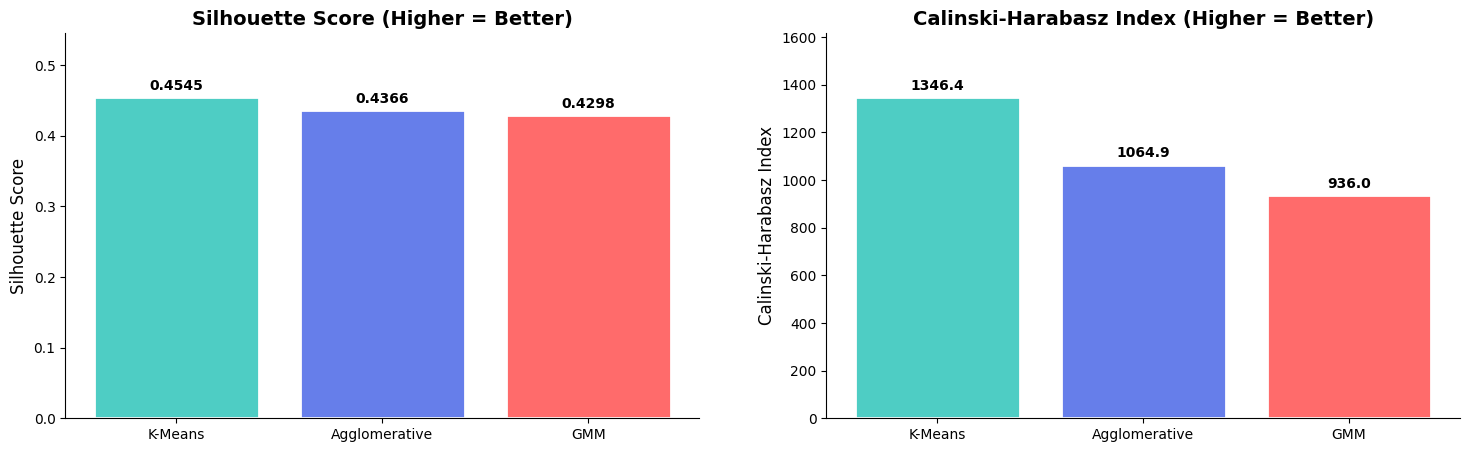

In [36]:
# Visualization: Model Comparison Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

models = comparison_df['Model'].tolist()
colors = ['#4ECDC4', '#667eea', '#FF6B6B', '#764ba2'][:len(models)]

# Silhouette Score (higher is better)
ax1 = axes[0]
bars1 = ax1.bar(models, comparison_df['Silhouette Score'], color=colors, edgecolor='white', linewidth=2)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score (Higher = Better)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(comparison_df['Silhouette Score']) * 1.2)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Calinski-Harabasz (higher is better)
ax2 = axes[1]
bars2 = ax2.bar(models, comparison_df['Calinski-Harabasz'], color=colors, edgecolor='white', linewidth=2)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=12)
ax2.set_title('Calinski-Harabasz Index (Higher = Better)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(comparison_df['Calinski-Harabasz']) * 1.2)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)



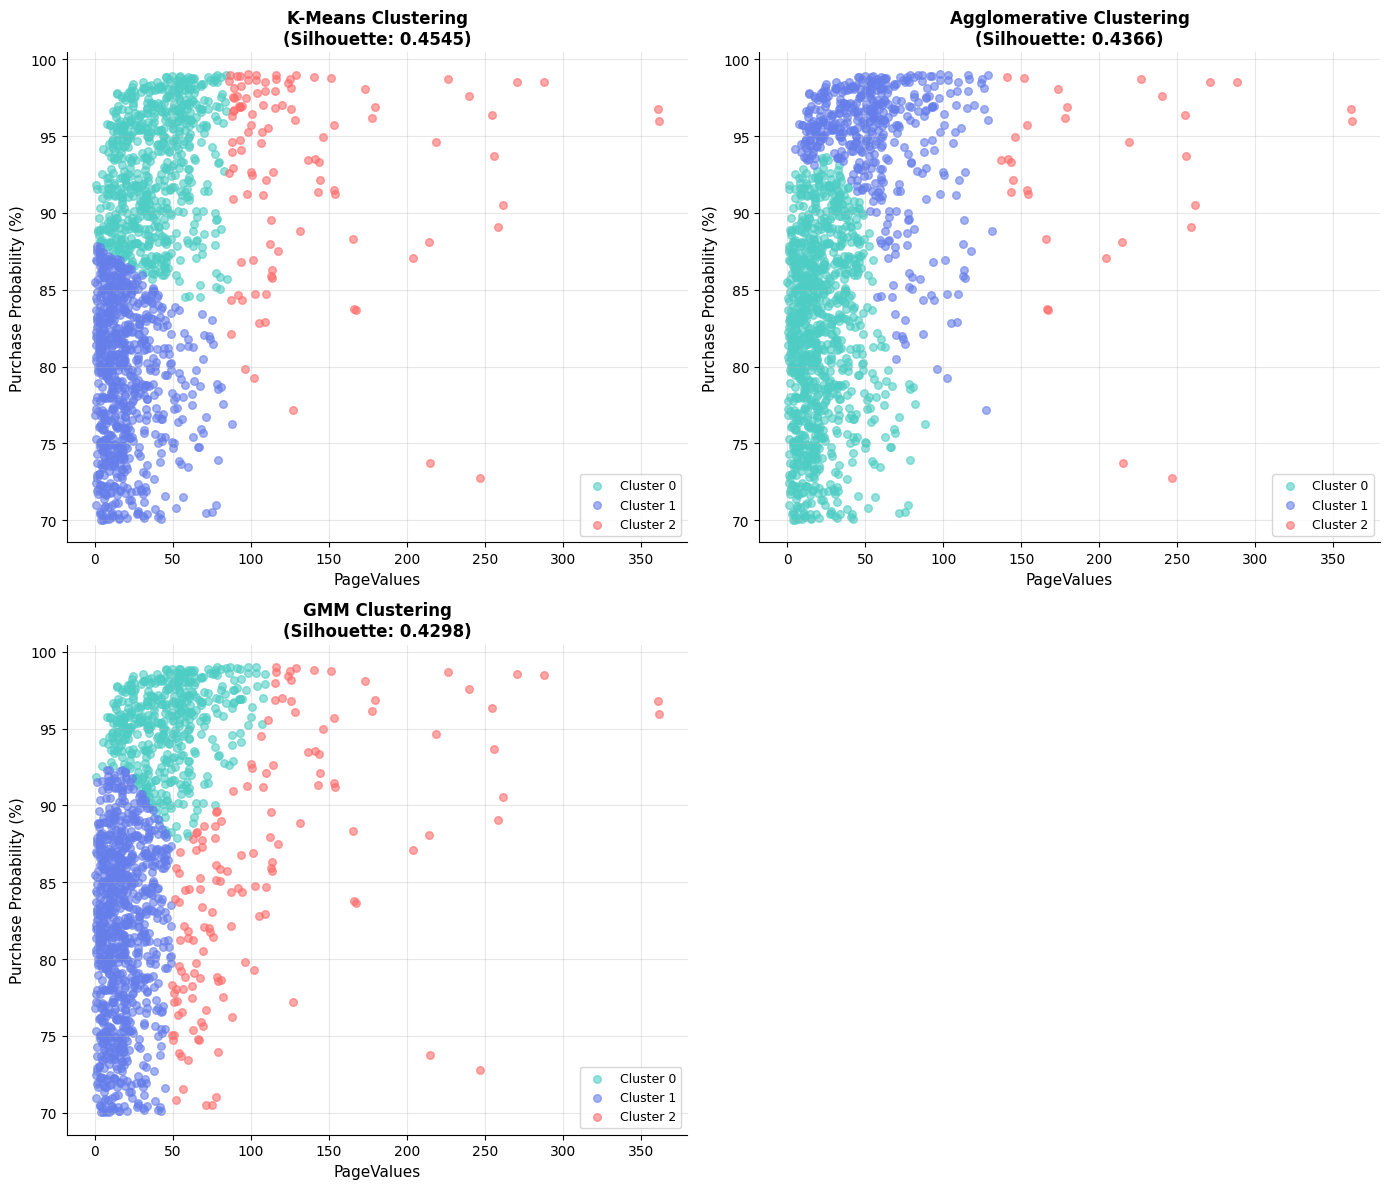


📊 Chart saved to exports/charts/clustering_scatter_comparison.png


In [37]:
# Visualization: Scatter plots showing clustering results for each model
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

cluster_colors = ['#4ECDC4', '#667eea', '#FF6B6B', '#764ba2', '#2ECC71']

for idx, (model_name, labels) in enumerate(cluster_labels_dict.items()):
    ax = axes[idx]
    
    # Get unique labels (excluding noise for DBSCAN)
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        mask = labels == label
        if label == -1:
            # Noise points in DBSCAN
            ax.scatter(hp_df.loc[mask, 'PageValues'], 
                      hp_df.loc[mask, 'Purchase_Probability_Clean'] * 100,
                      c='gray', alpha=0.3, s=20, label='Noise')
        else:
            ax.scatter(hp_df.loc[mask, 'PageValues'], 
                      hp_df.loc[mask, 'Purchase_Probability_Clean'] * 100,
                      c=cluster_colors[label % len(cluster_colors)], 
                      alpha=0.6, s=30, label=f'Cluster {label}')
    
    ax.set_xlabel('PageValues', fontsize=11)
    ax.set_ylabel('Purchase Probability (%)', fontsize=11)
    ax.set_title(f'{model_name} Clustering\n(Silhouette: {cluster_results[model_name]["Silhouette Score"]:.4f})', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

# Hide empty subplot if less than 4 models
for idx in range(len(cluster_labels_dict), 4):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('exports/charts/clustering_scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Chart saved to exports/charts/clustering_scatter_comparison.png")

## Associate Rule Mining

In [40]:
arm_df = pd.DataFrame()

In [41]:
# Discretize PageValues (0, Low, High)
arm_df['High_PageValue'] = df['PageValues'] > df['PageValues'].median()

In [42]:
# Discretize ExitRates (High Exit Rate is usually bad)
arm_df['High_ExitRate'] = df['ExitRates'] > df['ExitRates'].median()

In [43]:
# Keep existing Categorical/Boolean features
arm_df['Is_Revenue'] = df['Revenue']
arm_df['Is_Weekend'] = df['Weekend']
arm_df['Is_Returning_Visitor'] = df['VisitorType'] == 'Returning_Visitor'
arm_df['Is_New_Visitor'] = df['VisitorType'] == 'New_Visitor'

In [44]:
# Add Month (One-hot encoding)
month_dummies = pd.get_dummies(df['Month'], prefix='Month')
arm_df = pd.concat([arm_df, month_dummies], axis=1)

In [45]:
# Ensure all columns are boolean (required for mlxtend)
arm_df = arm_df.astype(bool)

In [46]:
# 3. Apply Apriori Algorithm
# We set a minimum support (e.g., 5% of all transactions)
frequent_itemsets = apriori(arm_df, min_support=0.05, use_colnames=True)

In [47]:
# 4. Generate Association Rules
# We use 'lift' as the metric to find strong relationships
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

In [48]:
# 5. Filter for rules where consequent is ONLY Is_Revenue (avoid duplicates)
revenue_rules = rules[rules['consequents'].apply(lambda x: x == frozenset({'Is_Revenue'}))]

In [49]:
# Sort by Lift to see the strongest patterns
revenue_rules = revenue_rules.sort_values(by='lift', ascending=False)

In [50]:
print("Top 5 Rules Leading to Purchases:")
print(revenue_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Top 5 Rules Leading to Purchases:
                               antecedents   consequents   support  \
0                         (High_PageValue)  (Is_Revenue)  0.126014   
4   (High_PageValue, Is_Returning_Visitor)  (Is_Revenue)  0.097911   
2                              (Month_Nov)  (Is_Revenue)  0.062270   
14       (Month_Nov, Is_Returning_Visitor)  (Is_Revenue)  0.051536   

    confidence      lift  
0     0.563370  3.603737  
4     0.512216  3.276518  
2     0.254863  1.630292  
14    0.247540  1.583454  


## Visualizing Top 5 Association Rules Leading to Purchases

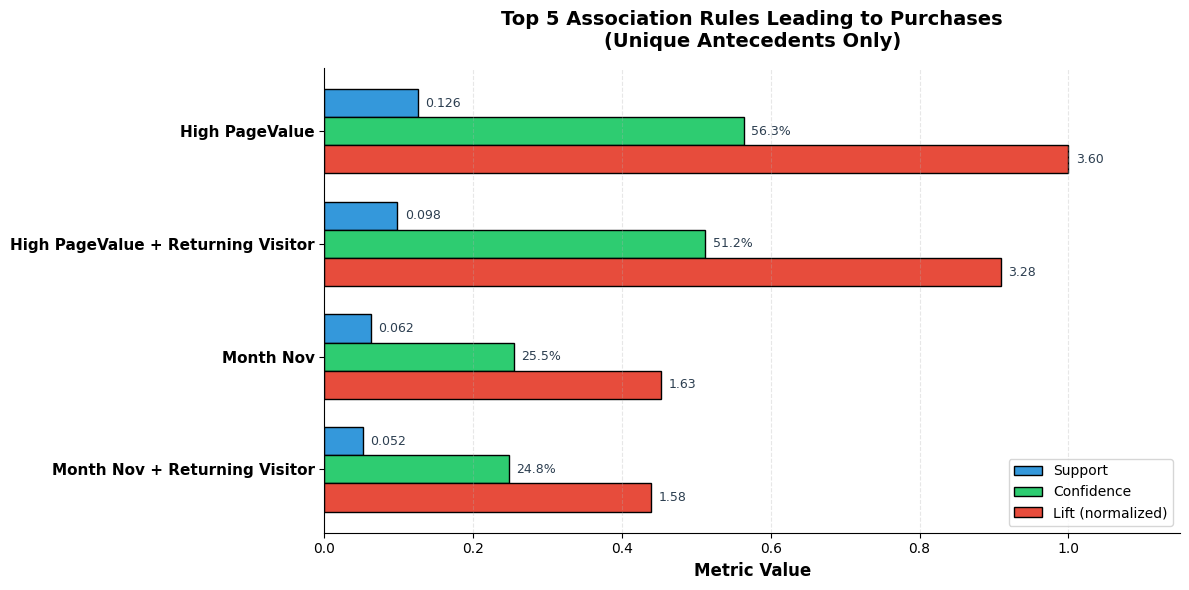


TOP 5 ASSOCIATION RULES SUMMARY

1. High PageValue → Revenue
   Support: 0.1260 | Confidence: 56.3% | Lift: 3.60

2. High PageValue + Returning Visitor → Revenue
   Support: 0.0979 | Confidence: 51.2% | Lift: 3.28

3. Month Nov → Revenue
   Support: 0.0623 | Confidence: 25.5% | Lift: 1.63

4. Month Nov + Returning Visitor → Revenue
   Support: 0.0515 | Confidence: 24.8% | Lift: 1.58


In [51]:
# Get top 5 unique rules (drop duplicate antecedents, keep highest lift)
top_5_rules = revenue_rules.drop_duplicates(subset=['antecedents'], keep='first').head(5).copy()

# Create clean, readable rule labels
top_5_rules['rule_label'] = top_5_rules['antecedents'].apply(
    lambda x: ' + '.join([str(item).replace('_', ' ').replace('Is ', '').replace('High ', 'High ') 
                          for item in x])
)

# Single clean bar chart with all metrics
fig, ax = plt.subplots(figsize=(12, 6))

# Bar positions
y_pos = range(len(top_5_rules))
bar_height = 0.25

# Create grouped bars
bars1 = ax.barh([y - bar_height for y in y_pos], top_5_rules['support'], 
                height=bar_height, color='#3498db', edgecolor='black', label='Support')
bars2 = ax.barh(y_pos, top_5_rules['confidence'], 
                height=bar_height, color='#2ecc71', edgecolor='black', label='Confidence')
bars3 = ax.barh([y + bar_height for y in y_pos], top_5_rules['lift'] / top_5_rules['lift'].max(), 
                height=bar_height, color='#e74c3c', edgecolor='black', label='Lift (normalized)')

# Add value labels
for i, (s, c, l) in enumerate(zip(top_5_rules['support'], top_5_rules['confidence'], top_5_rules['lift'])):
    ax.text(s + 0.01, i - bar_height, f'{s:.3f}', va='center', fontsize=9, color='#2c3e50')
    ax.text(c + 0.01, i, f'{c:.1%}', va='center', fontsize=9, color='#2c3e50')
    ax.text(l/top_5_rules['lift'].max() + 0.01, i + bar_height, f'{l:.2f}', va='center', fontsize=9, color='#2c3e50')

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(top_5_rules['rule_label'], fontsize=11, fontweight='bold')
ax.set_xlabel('Metric Value', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Association Rules Leading to Purchases\n(Unique Antecedents Only)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("TOP 5 ASSOCIATION RULES SUMMARY")
print("="*70)
for i, (_, row) in enumerate(top_5_rules.iterrows(), 1):
    print(f"\n{i}. {row['rule_label']} → Revenue")
    print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}")

ChartResponse(type='chart', value='exports\\charts\\temp_chart_8b347f56-c61e-4c6c-9e90-55d7be016a80.png')

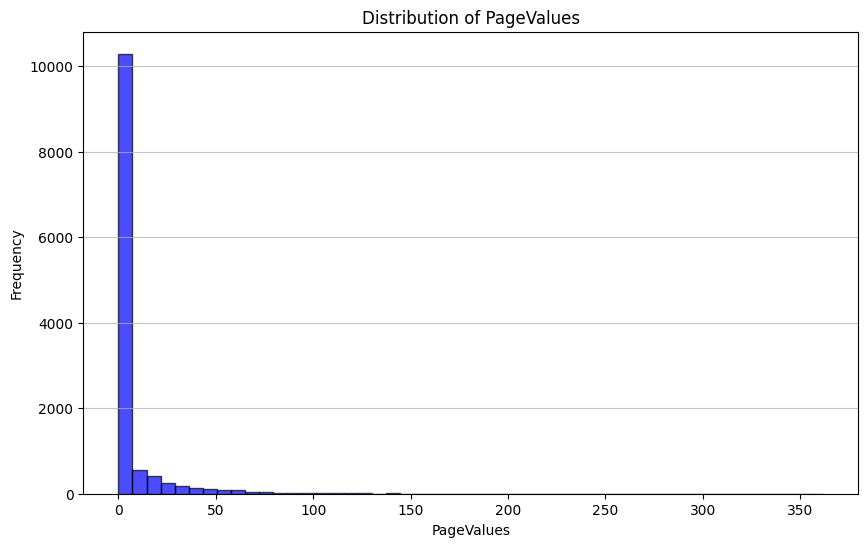

In [7]:
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM


df=pai.read_csv("online_shoppers_intention.csv")
llm = LiteLLM(
    model="nvidia_nim/meta/llama-3.1-405b-instruct",
    api_key="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",
    stream=False,
)
    
pai.config.set({"llm": llm, "save_charts": False,"verbose": False})
df.chat("Plot the distribution of PageValues and explain any insights you can derive from it.")
    